Dean Hickman

Spring 2025

CS 343: Neural Networks

# Project 0 | Scientific Python

This is a short project aimed at refreshing your memory of numpy, pandas, vectorized programming, and plotting. The focus is practicing common operations that will come up all semester with simple examples.

**Reminders and notes**:
- Submit rubric on Google Classroom (one person per team).
- Submit code as a .zip file named `username_final.zip`.
- Fill out the team work Google Form linked to on Google Classroom (everyone does this).
- There should be ZERO loops of any kind below!
- If you are doing extensions, remember that they are being graded based on the 5 minute video that record and submit with your project.
- All files should be inside the .zip file.

In [280]:
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import pandas as pd


# Set the color style so that I can see your plots
plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
# Make the font size larger
plt.show()
plt.rcParams.update({'font.size': 18})

# Turn off scientific notation when printing
np.set_printoptions(suppress=True, precision=3)

## Task 1: Common shape operations

1. Create an ndarray of values drawn from a Gaussian mean 0 stdev 0.5 with shape `(3, 2, 3, 1, 5)`. Do this the way we discussed in class, with a seed of 2.

In [281]:
np.random.seed(2)  # Keep these random seeds for test code purposes
mu, sigma = 0, 0.5
attractor = np.random.normal(mu, sigma, size = (3,2,3,1,5))
print(attractor)

[[[[[-0.208 -0.028 -1.068  0.82  -0.897]]

   [[-0.421  0.251 -0.623 -0.529 -0.455]]

   [[ 0.276  1.146  0.021 -0.559  0.27 ]]]


  [[[-0.298 -0.01   0.588 -0.374  0.005]]

   [[-0.439 -0.078  0.128 -0.494 -0.169]]

   [[-0.118 -0.319 -0.594 -0.711 -0.077]]]]



 [[[[-0.135  1.116 -1.217  0.056  0.185]]

   [[ 0.68   0.251 -0.422  0.     0.271]]

   [[-0.157  0.386 -0.934  0.866  0.734]]]


  [[[-0.168  0.306  0.024 -0.415  0.044]]

   [[ 0.5   -0.191 -0.188 -0.037  0.217]]

   [[ 0.639 -0.317  0.254  0.108 -0.929]]]]



 [[[[-0.21  -0.066 -0.02   0.163 -1.02 ]]

   [[ 0.023 -0.339 -0.72   0.262  0.368]]

   [[-0.327  0.421 -0.191  0.033 -0.549]]]


  [[[ 0.792 -1.33  -0.046  0.348 -1.017]]

   [[-0.095 -0.039  0.412  0.624 -0.202]]

   [[-0.692  0.684  0.609 -0.231  0.175]]]]]


In [282]:
print(f'Your shape is {attractor.shape} and should be (3, 2, 3, 1, 5)')
print(f'Your first 3 numbers are\n{attractor[0,0,0,0,:3]}\nand should be\n [ 0.095 -0.261 -0.207]]')



Your shape is (3, 2, 3, 1, 5) and should be (3, 2, 3, 1, 5)
Your first 3 numbers are
[-0.208 -0.028 -1.068]
and should be
 [ 0.095 -0.261 -0.207]]


I think that the test code target values were generated with a seed that was not 2. I ran test code to find the seed that would yield the target but for seeds up to 1000, the target values dow not exist. 

2. Reshape your array so that it has a leading singleton dimension

In [283]:
attractor1 = np.reshape(attractor, (1,3,2,3,1,5))


In [284]:
print(f'Your shape is {attractor1.shape} and should be (1, 3, 2, 3, 1, 5)')

Your shape is (1, 3, 2, 3, 1, 5) and should be (1, 3, 2, 3, 1, 5)


3. Remove singleton dimensions

In [285]:
attractor2 = np.reshape(attractor1, (3,2,3,5))

In [286]:
print(f'Your shape is {attractor2.shape} and should be (3, 2, 3, 5)')

Your shape is (3, 2, 3, 5) and should be (3, 2, 3, 5)


4. Reshape your ndarray to merge non-leading dimensions. No hard coding!

In [287]:
attractor3= np.reshape(attractor2, (3, 30))


In [288]:
print(f'Your shape is {attractor3.shape} and should be (3, 30)')
print(f'Your 2nd row of 1st 3 numbers is\n{attractor3[1,:3]} and should be\n[0.421 0.064 0.539]')

Your shape is (3, 30) and should be (3, 30)
Your 2nd row of 1st 3 numbers is
[-0.135  1.116 -1.217] and should be
[0.421 0.064 0.539]


I'm going to assume here that the seed is still incorrect. Given the scope of how "attractor{n}" are being created my seed is still 2, so the test code targets are from a distribution seeded on another value.

5. Print the number of total elements in `gauss`

In [289]:
import math
element_tot= math.prod(attractor3.shape)  

In [290]:
print(f'You should get 90 and you got {element_tot}')

You should get 90 and you got 90


6. Figure out how to permute (swap) the dimensions of the ndarray `x` in the cell below from shape=(5, 2, 3) to (3, 5, 2). You should do this in one line of code and is relatively simple. *The long text below is just to give you an intuition why this problem will come up in class this semester when working with image data.*

**Intuition:** There is an image consisting of a 5x2 grid of RGB values (i.e. 5x2x3): `[(R1,G1,B1), (R2,G2,B2)], [(R1,G1,B1), (R2,G2,B2)], ...`. We want to shuffle this up so that all the R values are grouped together (rather than being next to the G and B values). We also want to arrange each of the color values in a grid that matches the height and width of the original image (5x2). So the interpretation now is that we have 3 grayscale images: one made up of only the R values (in a 5x2 grid), one made up only of G values, and one made up only of B values.

**Visually**:

Original `x`:

    array([[[ 1.764,  0.4  ,  0.979],
            [ 2.241,  1.868, -0.977]],

           [[ 0.95 , -0.151, -0.103],
            [ 0.411,  0.144,  1.454]],

           [[ 0.761,  0.122,  0.444],
            [ 0.334,  1.494, -0.205]],

           [[ 0.313, -0.854, -2.553],
            [ 0.654,  0.864, -0.742]],

           [[ 2.27 , -1.454,  0.046],
            [-0.187,  1.533,  1.469]]])
    

Answer `x_p`:

    array([[[ 1.764,  2.241],
            [ 0.95 ,  0.411],
            [ 0.761,  0.334],
            [ 0.313,  0.654],
            [ 2.27 , -0.187]],

           [[ 0.4  ,  1.868],
            [-0.151,  0.144],
            [ 0.122,  1.494],
            [-0.854,  0.864],
            [-1.454,  1.533]],

           [[ 0.979, -0.977],
            [-0.103,  1.454],
            [ 0.444, -0.205],
            [-2.553, -0.742],
            [ 0.046,  1.469]]])

In [291]:
# don't change this (but do execute it). This is for test code
x_p_sol = np.array([[[ 1.764,  2.241],
            [ 0.95 ,  0.411],
            [ 0.761,  0.334],
            [ 0.313,  0.654],
            [ 2.27 , -0.187]],

           [[ 0.4  ,  1.868],
            [-0.151,  0.144],
            [ 0.122,  1.494],
            [-0.854,  0.864],
            [-1.454,  1.533]],

           [[ 0.979, -0.977],
            [-0.103,  1.454],
            [ 0.444, -0.205],
            [-2.553, -0.742],
            [ 0.046,  1.469]]])

In [292]:
np.random.seed(0)  # keep me
x = np.random.randn(5, 2, 3)

x_p = np.transpose(x, (2, 0, 1))



In [293]:
print(f'The shape of x_p is {x_p.shape} and should be (3, 5, 2)')
print('Your array below should match x_p above:\n', x_p)
print(f'...and they match? {np.allclose(x_p_sol, x_p, rtol=1e-1)}')

The shape of x_p is (3, 5, 2) and should be (3, 5, 2)
Your array below should match x_p above:
 [[[ 1.764  2.241]
  [ 0.95   0.411]
  [ 0.761  0.334]
  [ 0.313  0.654]
  [ 2.27  -0.187]]

 [[ 0.4    1.868]
  [-0.151  0.144]
  [ 0.122  1.494]
  [-0.854  0.864]
  [-1.454  1.533]]

 [[ 0.979 -0.977]
  [-0.103  1.454]
  [ 0.444 -0.205]
  [-2.553 -0.742]
  [ 0.046  1.469]]]
...and they match? True


7. The following ndarray has a `uint8` datatype (`dtype` in numpy parlance). Cast the ndarray into a `float64` dtype, the normalize the values so that the (0, 255) uint8 values (the smallest and largest possible values) become (0.0, 1.0) float64 values.

**Note:** Only 255 should map to 1.0. If 255 were not max value presently in the input vector, you shouldn't have a 1.0 in the float64 array.

*Data from images often come in as `uint8` (0 to 255 ints) but neural networks tend to work with continuous real values, and best with normalized inputs.*

In [294]:
u = np.uint8([7, 4, 20, 22, 3])
u = u.astype(np.float64) #cast as float64. Ndarray has no attribute astype so u.np.asfloat64() is incorrect synatx 
u = u / 255.0 #normalize (0, 255) to (0, 1) 




In [295]:
print(f'The min is {u.min():.4f}, the max is {u.max():.4f}.\nThey should be 0.0118 and 0.0863')
print(f'The type is {u.dtype} and should be float64.')

The min is 0.0118, the max is 0.0863.
They should be 0.0118 and 0.0863
The type is float64 and should be float64.


## Task 2: Matrix multiplication and operations

1. Define ndarray `a` of all 5s (`shape=(8,31)`). Define ndarray `b` of ints 0 thru 7 (`shape=(8,)`), no hard coding!

In [296]:
a = np.full((8, 31), 5)
b = np.arange(8).reshape(8,)

In [297]:
print(f'Your a shape is {a.shape}, and should be (8, 31).')
print(f'All your a values == 7? {np.all(a == 5)}')
print(f'Your b shape is {b.shape}, and should be (8,).')
print(f'Min of b is 0? {b.min() == 0}. Max of b is 7? {b.max() == 7}')

Your a shape is (8, 31), and should be (8, 31).
All your a values == 7? True
Your b shape is (8,), and should be (8,).
Min of b is 0? True. Max of b is 7? True


2. Matrix multiply the ndarrays in the order "a times b" a way to get `c` with dimensions (31,). **This should be a one-liner!**

In [298]:
c= np.matmul(a.T, b)

In [299]:
print(f'Your c shape is {c.shape}, and should be (31,).')
print(f'All your c values == 140? {np.all(c == 140.)}')

Your c shape is (31,), and should be (31,).
All your c values == 140? True


3. Sum across your `a` array along the last axis, preserving the number of dimensions

In [300]:
a_sum = np.sum(a, axis= 1)

In [301]:
print(f'Your a_sum shape is {a_sum.shape}, and should be (8, 1).')
print(f'All your a_sum values == 155? {np.all(a_sum == 155.)}')

Your a_sum shape is (8,), and should be (8, 1).
All your a_sum values == 155? True


4. Standardize the following following array in 1 line of code. Recall the equation is $$x_s = \frac{x-\mu}{\sigma}$$

In [302]:
np.random.seed(0)  # keep me!
x = np.random.normal(loc=10, scale=0.5, size=(5,))
x_s = (x- np.mean(x))/ np.std(x)



In [303]:
print(f'Your standardized array is\n{x_s}\nand should be\n[ 0.471 -1.575 -0.707  1.186  0.626]')

Your standardized array is
[ 0.471 -1.575 -0.707  1.186  0.626]
and should be
[ 0.471 -1.575 -0.707  1.186  0.626]


5. Perform min-max normalization on the following array so that min and max of each variable (column) is 0 and 1, respectively. Write code that verifies that `x` has been min-max normalized correctly.

In [304]:
np.random.seed(0)  # keep me!
x = np.random.uniform(low=-5, high=10, size=(6,3))

x_norm = (x - np.min(x, axis = 0))/ (np.max(x, axis = 0) - np.min(x, axis = 0))

In [305]:
print(f'The column mins of the normalized array is\n{np.min(x_norm, axis=0)}\nand should be\n[0. 0. 0.]')
print(f'The column maxs of the normalized array is\n{np.max(x_norm, axis=0)}\nand should be\n[1. 1. 1.]')

The column mins of the normalized array is
[0. 0. 0.]
and should be
[0. 0. 0.]
The column maxs of the normalized array is
[1. 1. 1.]
and should be
[1. 1. 1.]


6. Center the following array that has 4 columns (variables). Write code that verifies that `x` has been centered correctly. *Having `-0.` entries is ok.*

In [306]:
np.random.seed(0)  # keep me!
x = np.random.uniform(low=-5, high=10, size=(5,4))

x_c = (x - np.mean(x, axis= 0)) #subtract the mean from each data point 


print(np.mean(x_c, axis = 0)) #verify be ensuring the column means are all 0 


[ 0. -0.  0. -0.]


In [307]:
print(f'The column means are\n{x_c.mean(0)}\nand should be\n[ 0. -0.  0. -0.]')

The column means are
[ 0. -0.  0. -0.]
and should be
[ 0. -0.  0. -0.]


## Task 3: Indexing

1. Replace all values < 0 with -1, all values >= 0 with +1. Can be done with a one-liner.

In [308]:
np.random.seed(0)  # keep me!
rand_vals = np.random.uniform(low=-5, high=4, size=(25, 25))

#rand_vals = np.where((rand_vals < 0), -1 , rand_vals) and np.where((rand_vals >= 0), 1, rand_vals)

rand_vals = np.select([rand_vals < 0, rand_vals >= 0], [-1, 1])



In [309]:
print(f'Number of -1s is {np.count_nonzero(rand_vals == -1)} and should be 347.')
print(f'Number of +1s is {np.count_nonzero(rand_vals == 1)} and should be 278.')

Number of -1s is 347 and should be 347.
Number of +1s is 278 and should be 278.


2. Use logical indexing to select values greater than 10, assign them to a new array `x_10`. The correct solution does not involve tuples.

In [310]:
np.random.seed(0)  # keep me!
x = np.random.randint(low=0, high=21, size=(10))

x_10 = x[ x > 10]

In [311]:
print(f'Values > 10 are: {x_10} and should be [12 15 19 18]')
print('(If your order of values is different, that is ok.)')

Values > 10 are: [12 15 19 18] and should be [12 15 19 18]
(If your order of values is different, that is ok.)


3. Figure out how to convert (row, col) **subscript (tuple) indices** to a **linear (flat) index**. *Hint*: There is a Numpy function that does the heavy lifting. It should work on the following test case:

*Example:* If the (row, col) = (5, 5) in an ndarray with shape=(100, 30), the linear index should be 155.

In [312]:
dims= (5,5)
linInd= np.ravel_multi_index(dims, (100, 30))

In [313]:
print(f'Your linear index is {linInd} and should be 155')

Your linear index is 155 and should be 155


4. Figure out how to go in the other direction, go from linear index to subscript index. It should work on the following test case:

The linear index 155 maps to (row, col) = (5, 5) in an ndarray with `shape=(100, 30)`.

In [314]:
subs= np.unravel_index(linInd, shape = (100, 30))

In [315]:
print(f'Your subscripts are {subs} and should be (5, 5)')

Your subscripts are (5, 5) and should be (5, 5)


5. Use column `arange` indexing to make:
- the 1st 3 rows of the first column 1s
- rows 4-6 of the third column 1s.
- rows 7-8 of the second column 1s.

There's no need to do this in one line of code (i.e. multiple lines of code are fine)! The cell below should print:

    [[1. 0. 0.]
     [1. 0. 0.]
     [1. 0. 0.]
     [0. 0. 1.]
     [0. 0. 1.]
     [0. 0. 1.]
     [0. 1. 0.]
     [0. 1. 0.]]

In [316]:
x = np.zeros((8,3), dtype = int)

x[np.arange(3), 0] = 1
x[np.arange(3,6), 2] = 1
x[np.arange(6,8), 1] = 1


In [317]:
print(x)

[[1 0 0]
 [1 0 0]
 [1 0 0]
 [0 0 1]
 [0 0 1]
 [0 0 1]
 [0 1 0]
 [0 1 0]]


6. In one line of code (using indexing), assign 5s between the 9th and 15th (inclusive) rows and columns (a square chunk of the 2D array). **Careful with off by one errors.**

In [318]:
x = np.zeros((25, 25))

x[9:16, 9:16] = 5

x_1= x[9:16, 9:16]
print(x_1.shape)

(7, 7)


In [319]:
print(f'No rouge elements in your array? {np.all(np.unique(x) == np.array([0, 5]))}')
print(f'Total number of 5s correct? {np.sum(x) == 245}')


No rouge elements in your array? True
Total number of 5s correct? True


7. Reverse elements in the following ndarray in axes 1 and 2 only (0 being the "1st axis").

In [320]:
np.random.seed(0)
x = np.random.randn(6, 8, 12, 14, 16)
x= np.flip(x, (1,2))



In [321]:
print('Your 1st 2 elements of the result in each dim (flattened) are\n', x[:2, :2, :2, :2, :2].flatten())
print('They should be')
x_sol = np.array([ 0.384, -3.084,  0.302, -0.511,  0.691,  0.441,  0.943,  2.123,
        0.339,  0.328,  2.297,  0.186,  0.162,  0.953,  0.281,  0.97 ,
        0.116,  1.595, -1.702, -0.934, -0.617,  0.717, -0.856, -0.565,
       -0.682,  0.534, -1.018, -0.074,  0.758, -1.447,  1.651,  0.81 ])
print(x_sol)


Your 1st 2 elements of the result in each dim (flattened) are
 [ 0.384 -3.084  0.302 -0.511  0.691  0.441  0.943  2.123  0.339  0.328
  2.297  0.186  0.162  0.953  0.281  0.97   0.116  1.595 -1.702 -0.934
 -0.617  0.717 -0.856 -0.565 -0.682  0.534 -1.018 -0.074  0.758 -1.447
  1.651  0.81 ]
They should be
[ 0.384 -3.084  0.302 -0.511  0.691  0.441  0.943  2.123  0.339  0.328
  2.297  0.186  0.162  0.953  0.281  0.97   0.116  1.595 -1.702 -0.934
 -0.617  0.717 -0.856 -0.565 -0.682  0.534 -1.018 -0.074  0.758 -1.447
  1.651  0.81 ]


8. Create an array called `mask` that has the same shape as `arr` and fill it with `True` everywhere a number larger than 1 appears in the corresponding position of `arr`, `False` otherwise. This type of array is called a **mask** of `arr`.

In [322]:
np.random.seed(0)

arr = np.random.uniform(low=0, high=2, size=(5, 5))
masked_arr= ma.masked_where( arr > 1, arr)
mask= masked_arr.mask


In [323]:
print(mask)
print('Your mask array should look like:')
print('''[[ True  True  True  True False]
 [ True False  True  True False]
 [ True  True  True  True False]
 [False False  True  True  True]
 [ True  True False  True False]]''')

[[ True  True  True  True False]
 [ True False  True  True False]
 [ True  True  True  True False]
 [False False  True  True  True]
 [ True  True False  True False]]
Your mask array should look like:
[[ True  True  True  True False]
 [ True False  True  True False]
 [ True  True  True  True False]
 [False False  True  True  True]
 [ True  True False  True False]]


## Task 4: Plotting and loading data

1. Use matplotlib to create a nicely formatted plot of $1/\left (1+e^{-x} \right )$ and $1/\left (1+e^{x} \right )$ evaluated from -6 to 6. Choose an x sampling rate so that the curves look smooth (**no jagged edges!!**). Make sure to


- make $1/\left (1+e^{-x} \right )$ red and dashed
- make $1/\left (1+e^{x} \right )$ blue and dotted
- set the y range in view to -0.1 to 1.1.
- include a *useful* legend
- include x and y axis labels
- include a *useful* title

Executing the cell below should generate the plot include WITHOUT any weird outputs about plot object

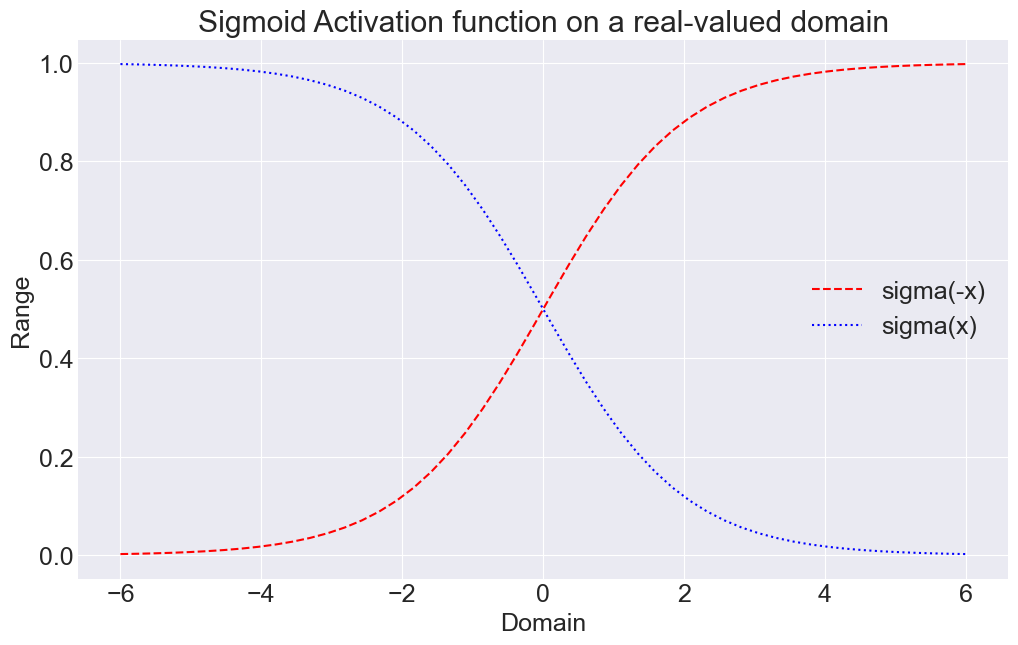

In [324]:
x= np.linspace(-6,6)
y = np.linspace(-0.1, 1.1)
y1 = (1 / (1 + (np.e** (-x))))
y2 = (1 / (1 + (np.e**x)))
fig, ax = plt.subplots(figsize= (12, 7))
ax.plot(x, y1, color ='red', linestyle = 'dashed', label = 'sigma(-x)')
ax.plot(x, y2, color ='blue', linestyle = 'dotted', label = 'sigma(x)')
ax.set_xlabel("Domain")
ax.set_ylabel("Range")
y = np.linspace(-0.1, 1.1)
ax.set_title("Sigmoid Activation function on a real-valued domain")
ax.legend()
plt.show()

2. Use `pandas` to download and open the Iris dataset over the internet (should run if data CSV file NOT present in your working directory). Create a DataFrame object `df` with the 1st two features and the species names (currently strings) coded categorically as ints.

The url for the data is: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data

Note that the above file does not include any headers and is in CSV format.

In [325]:
d = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
df= pd.read_csv(d, header = None)
df= df.iloc[:, [0,1,4]]
df.iloc[:, 2]= df.iloc[:, 2].astype("category").cat.codes
         

In [326]:
print(f'The first row is\n{df.iloc[0,:].to_numpy()} and should be\n[5.1 3.5 0. ]')
print(f'The last row is\n{df.iloc[-1,:].to_numpy()} and should be\n[5.9 3.  2. ]')

The first row is
[5.1 3.5 0] and should be
[5.1 3.5 0. ]
The last row is
[5.9 3.0 2] and should be
[5.9 3.  2. ]


3. Convert the DataFrame to a ndarray and create a scatter plot of `df`. Color the points by their class label. The default white/gray/black color scheme is fine.


- Superimpose the line y = x - 2.25.
- Make the line colored red.
- Restrict the x bounds to [4, 8]
- Restrict the y bounds to [2, 5]

Executing the cell below should generate the plot include WITHOUT any weird outputs about plot object

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


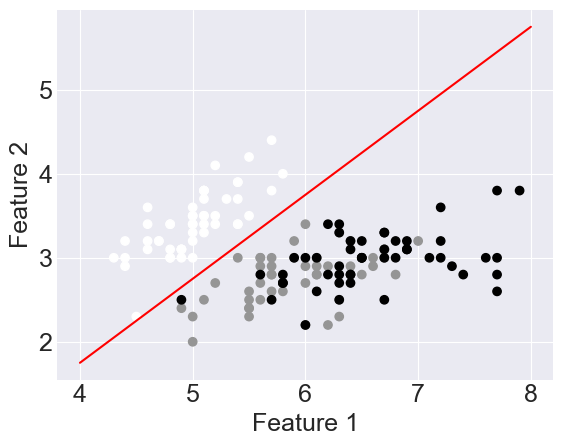

In [327]:
arr = df.to_numpy()
x = np.linspace(4, 8)
y = np.linspace(2, 5)
y = x - 2.25

fig, ax = plt.subplots()
ax.scatter(arr[:, 0], arr[:, 1], c = arr[:, 2] , cmap = 'Greys')
ax.plot(x, y, color = 'red', label= '')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.show()

4. Create a 2x2 grid of scatter plots with the following contents:


- (0,0): 2D Uniform random data
- (0,1): 2D isotropic (symmetric blob) Gaussian random data
- (1,0): 2D anisotropic (blob stretched out in a direction) Gaussian random data. Disregard RuntimeWarning messages if you are able to get the plot to look right.
- (1,1): The iris scatter plot
- Give your panels the titles a, b, c, d.

Make the figure large enough to be legible

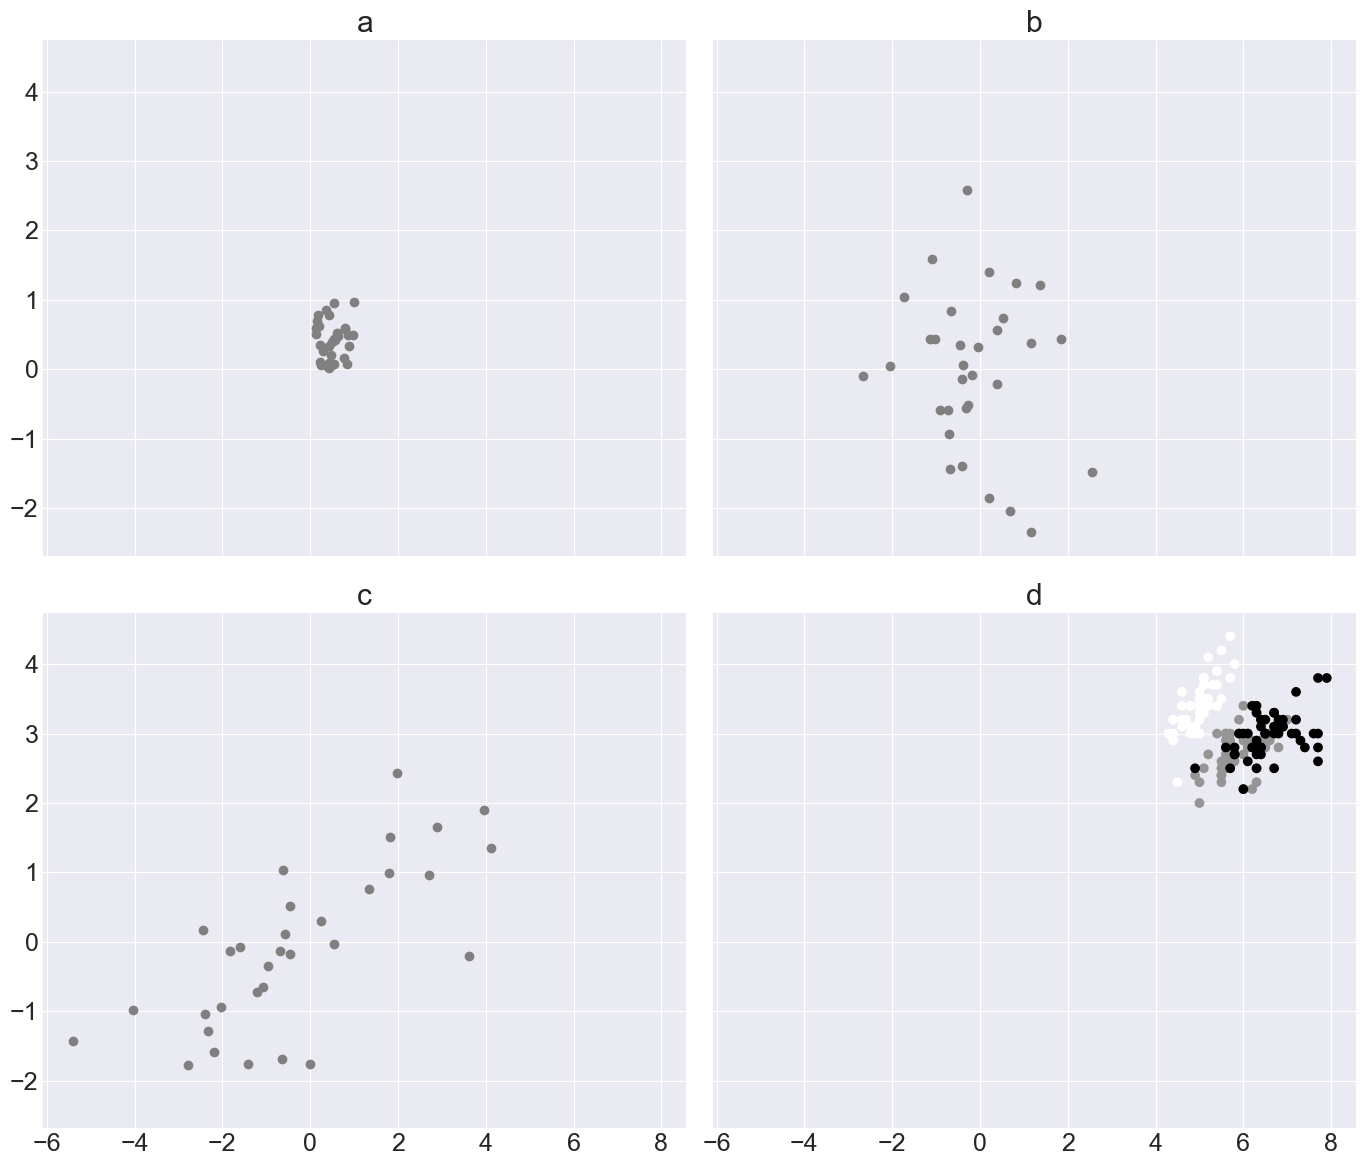

In [328]:
np.random.seed(2)
n = 32
aniso = np.array([[2, 1], [0.5, 1]])

unif = np.random.uniform(low = 0, high = 1, size=(n, 2))
gauss = np.random.normal(size=(n, 2))
gauss_skew = np.matmul(gauss, aniso.T)
fig, axs = plt.subplots(2,2 , figsize = (14, 12), sharex= 'all', sharey = 'all')


axs[0,0].scatter(unif[:, 0], unif[:, 1], color = 'Grey')
axs[0, 0].set_title('a')
axs[0,1].scatter(gauss[:, 0], gauss[:, 1], color = 'Grey')
axs[0, 1].set_title('b')
axs[1,0].scatter(gauss_skew[:, 0], gauss_skew[:, 1], color = 'Grey')
axs[1, 0].set_title('c')
axs[1,1].scatter(arr[:, 0], arr[:, 1], c = arr[:, 2] , cmap = 'Greys')
axs[1, 1].set_title('d')
plt.tight_layout()
plt.show()

5. Create a 2D heatmap plot of the function $$z(r, c) = \sqrt{sin(r)^2 + cos(0.1c)^2}$$ where $r$ stands for the row of a matrix and $c$ stands for the column of a matrix. Both the rows and columns should range from 0 to 99. That is, you are "plotting a 2D grid", where the entry in position (r, c) is given by $z(r, c)$.<br/><br/>Do this in matrix (image) coordinates rather than Cartesian coordinates — the plotted value corresponding to (0, 0) occupies the TOP-LEFT position of the plot.

For example, the row inputs (r) on a 3x3 grid would look like:

```
[[0 0 0]
 [1 1 1]
 [2 2 2]]
```

the column inputs (c) would look like:

```
[[0 1 2]
 [0 1 2]
 [0 1 2]]
```

#### Hints

- Check out the numpy function `meshgrid` and its optional arguments.
- Check out the matplotlib function `imshow`

<function matplotlib.pyplot.show(close=None, block=None)>

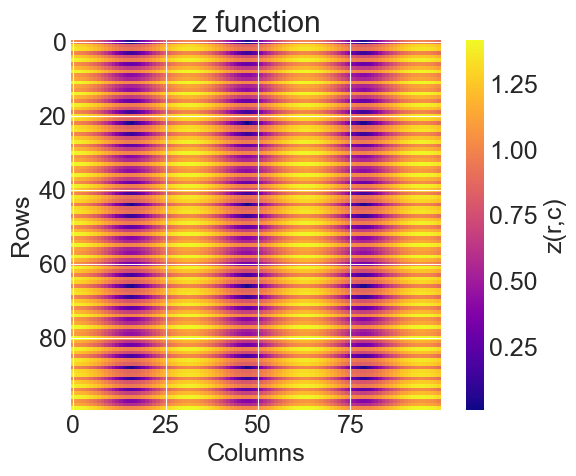

In [329]:
r, c = np.meshgrid(np.arange(100), np.arange(100), indexing= 'ij')

z = np.sqrt(np.sin(r)**2 + np.cos(0.1 * c)**2)

plt.imshow(z, cmap='plasma')
plt.colorbar(label='z(r,c)')
plt.title('z function')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show
